# Data Cleaning and Preprocessing

## Objectives

In this notebook, we prepare the Stack Overflow 2025 Developer Survey for exploratory analysis and predictive modeling by:

- selecting the study population
- handling missing values
- correcting data types
- identifying and treating outliers
- validating data quality
- exporting a cleaned dataset for subsequent analysis

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.utils import get_null_percentage

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

The raw dataset can be found in `data/raw/results.csv`. The remote dataset can be found [here](https://media.githubusercontent.com/media/StackExchange/Survey/refs/heads/main/packages/archive/2025/results.csv).


In [2]:
url = "../data/raw/results.csv"

df = pd.read_csv(url, low_memory=False)

df.head()


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


## Feature Selection

The following variables were selected based on their relevance to the research question, after an initial review of the survey schema. This selection may be refined throughout exploratory data analysis as data quality issues and additional insights are identified.

In [3]:
# Relevant Columns

relevant_columns = [
    "MainBranch",
    "Age",
    "EdLevel",
    "Employment",
    "WorkExp",
    "YearsCode",
    "DevType",
    "Industry",
    "Country",
    "ConvertedCompYearly",
    "ToolCountWork",
    "ToolCountPersonal",
    "OrgSize", 
    "RemoteWork", 
]

### 1. `MainBranch`

- **Rationale**: Defines the study population by identifying respondents who are professional developers. Used as a filtering variable rather than a predictor.

- **Verdict**: Keep

### 2. `Age`

- **Rationale**: Potential control variable to account for variation in developer salaries.

- **Verdict**: Keep

### 3. `EdLevel`

- **Rationale**: Core explanatory variable measuring respondents' highest level of formal education.

- **Verdict**: Keep

### 4. `Employment`

- **Rationale**: Potential control variable to account for differences in employment status that may influence compensation.

- **Verdict**: Keep

### 5. `WorkExp`

- **Rationale**: Core explanatory variable measuring professional work experience.

- **Verdict**: Keep

### 6. `YearsCode`

- **Rationale**: Measures total coding experience (professional and non-professional). Likely correlated with `WorkExp`; will be checked for multicollinearity and either combined, dropped, or used to isolate pre-professional coding time as a distinct effect.

- **Verdict**: Keep, pending collinearity check against `WorkExp`

### 7. `DevType`

- **Rationale**: Represents respondents' professional specialization (e.g., back-end, front-end, AI/ML, DevOps) and serves as the primary measure of specialization.

- **Verdict**: Keep

### 8. `ConvertedCompYearly`

- **Rationale**: Target variable representing respondents' annual compensation converted to a common currency (USD), making salaries comparable across countries.

- **Verdict**: Keep

### 9. `Industry`

- **Rationale**: Potential control variable capturing the industry in which respondents work, which may influence salary independently of education or experience.

- **Verdict**: Keep

### 10. `Country`

- **Rationale**: Controls for regional labor market and cost-of-living differences not captured by currency conversion alone. Without this, effects of education/experience/specialization on `ConvertedCompYearly` risk being confounded with geography.

- **Verdict**: Keep

### 11. `ToolCountWork`

- **Rationale**: Candidate proxy for technical breadth or workplace technology exposure. Doesn't map directly to education, experience, or specialization as defined — its relevance to the research question rather than a tangential/tooling angle will need to be justified before inclusion in modeling.

- **Verdict**: Evaluate — keep for EDA, justify or drop before modeling

### 12. `ToolCountPersonal`

- **Rationale**: Candidate proxy for personal technical engagement and breadth of technology use outside of work. Same concern as `ToolCountWork` — relevance to the core research question is indirect.

- **Verdict**: Evaluate — keep for EDA, justify or drop before modeling

### 13. `OrgSize` *(optional)*

- **Rationale**: Company size is a known salary driver independent of individual education/experience/specialization; may confound results if not controlled for, especially if senior/highly-educated respondents cluster at larger organizations.

- **Verdict**: Consider adding as a control variable

### 14. `RemoteWork` *(optional)*

- **Rationale**: Remote arrangements can shift pay relative to local market rate (e.g., geo-arbitrage) and may interact with `Country`. Adds rigor to the causal story but is not essential to the core question.

- **Verdict**: Consider adding as a control variable

## Subsetting the Dataset

In [4]:
# Extracting only relevant columns

df = df[relevant_columns]

df.head()

,MainBranch,Age,EdLevel,Employment,WorkExp,YearsCode,DevType,Industry,Country,ConvertedCompYearly,ToolCountWork,ToolCountPersonal,OrgSize,RemoteWork
0,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8.0,14.0,"Developer, mobile",Fintech,Ukraine,61256.0,7.0,3.0,20 to 99 employees,Remote
1,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,2.0,10.0,"Developer, back-end",Retail and Consumer Services,Netherlands,104413.0,6.0,5.0,500 to 999 employees,"Hybrid (some in-person, leans heavy to flexibi..."
2,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",10.0,12.0,"Developer, front-end",Software Development,Ukraine,53061.0,3.0,3.0,NaN,NaN
3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,4.0,5.0,"Developer, back-end",Retail and Consumer Services,Ukraine,36197.0,NaN,NaN,"10,000 or more employees",Remote
4,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",21.0,22.0,Engineering manager,Software Development,Ukraine,60000.0,4.0,3.0,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MainBranch           49191 non-null  str    
 1   Age                  49191 non-null  str    
 2   EdLevel              48149 non-null  str    
 3   Employment           48339 non-null  str    
 4   WorkExp              42893 non-null  float64
 5   YearsCode            43042 non-null  float64
 6   DevType              43680 non-null  str    
 7   Industry             33642 non-null  str    
 8   Country              35437 non-null  str    
 9   ConvertedCompYearly  23947 non-null  float64
 10  ToolCountWork        27611 non-null  float64
 11  ToolCountPersonal    25582 non-null  float64
 12  OrgSize              34178 non-null  str    
 13  RemoteWork           33780 non-null  str    
dtypes: float64(5), str(9)
memory usage: 5.3 MB


In [6]:
# Dropping all non-developer rows

df = (
        df[df["MainBranch"] == "I am a developer by profession"]
        .reset_index(drop=True)
     )

df.head()
df.shape

(37467, 14)

## Missing Values

In [7]:
df.isna().sum()

MainBranch                 0
Age                        0
EdLevel                  659
Employment               571
WorkExp                 2520
YearsCode               4087
DevType                 3781
Industry                9239
Country                10292
ConvertedCompYearly    17272
ToolCountWork          15670
ToolCountPersonal      17971
OrgSize                 8908
RemoteWork              9181
dtype: int64

In [8]:
get_null_percentage(df)

,Null Count,Null Percent
MainBranch,0.000000,0.000000
Age,0.000000,0.000000
EdLevel,0.017589,1.758881
Employment,0.015240,1.524008
WorkExp,0.067259,6.725919
YearsCode,0.109083,10.908266
DevType,0.100915,10.091547
Industry,0.246590,24.659033
Country,0.274695,27.469506
ConvertedCompYearly,0.460992,46.099234


## Investigating `ToolCountWork` and `ToolCountPersonal`

Estimating the relevance of these two features to the analysis, considering that they have a very high percentage of missing values.

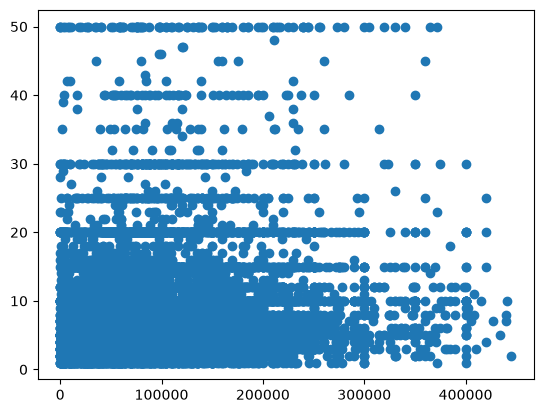

In [9]:
# ToolCountWork

salary_lower = df["ConvertedCompYearly"].quantile(0.01)
salary_upper = df["ConvertedCompYearly"].quantile(0.99)

tool_lower = df["ToolCountWork"].quantile(0.01)
tool_upper = df["ToolCountWork"].quantile(0.99)

# Removing extreme outliers to aid correct visualization

df_plot = df[
    df["ConvertedCompYearly"].between(salary_lower, salary_upper) &
    df["ToolCountWork"].between(tool_lower, tool_upper)
]


plt.scatter(x=df_plot["ConvertedCompYearly"], y=df_plot["ToolCountWork"])

In [10]:
# Pearson Correlation 

df[["ToolCountWork", "ConvertedCompYearly"]].corr()

,ToolCountWork,ConvertedCompYearly
ToolCountWork,1.000000,0.010218
ConvertedCompYearly,0.010218,1.000000


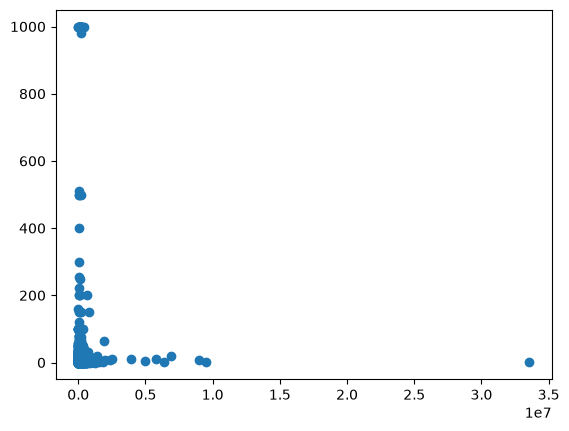

In [11]:
# ToolCountPersonal

salary_lower = df["ConvertedCompYearly"].quantile(0.01)
salary_upper = df["ConvertedCompYearly"].quantile(0.99)

tool_lower = df["ToolCountPersonal"].quantile(0.01)
tool_upper = df["ToolCountPersonal"].quantile(0.99)

# Removing extreme outlier to aid correct visualization

df_plot = df[
    df["ConvertedCompYearly"].between(salary_lower, salary_upper) &
    df["ToolCountPersonal"].between(tool_lower, tool_upper)
]

plt.scatter(x=df["ConvertedCompYearly"], y=df["ToolCountPersonal"])

In [12]:
# Pearson Correlation 

df[["ToolCountPersonal", "ConvertedCompYearly"]].corr()

,ToolCountPersonal,ConvertedCompYearly
ToolCountPersonal,1.000000,0.006959
ConvertedCompYearly,0.006959,1.000000


### Dropping `ToolCountWork` and `ToolCountPersonal`

ToolCountWork and ToolCountPersonal were initially considered as proxy measures of technical specialization. However, both variables contain over 40% missing values. Furthermore, it was observed from simple exploratory analysis that there is no clear trend between these variables and the target variable, `ConvertedCompYearly`. Relative to more direct measures of specialization such as `DevType`, they are less valuable to the research question. Given their substantial missingness and extremely weak correlation to the target variable, they will be excluded from subsequent analyses.

In [13]:
df = df.drop(columns=["ToolCountWork", "ToolCountPersonal"])

df.head()
df.shape

(37467, 12)

## Dropping rows with missing `ConvertedCompYearly`

`ConvertedCompYearly` is the target variable for this analysis. Observations with missing values for this variable were investigated to determine whether the annual compensation could be reconstructed from `CompTotal`. Since all rows with missing `ConvertedCompYearly` also had missing `CompTotal`, the missing values could not be recovered. Because imputing the target variable would introduce artificial salary values and potentially bias subsequent analyses, these observations were removed. Despite this reduction, the dataset retained over 20,000 observations, providing a sufficiently large sample for analysis.

In [14]:
df.loc[df["ConvertedCompYearly"].isna()].head()

,MainBranch,Age,EdLevel,Employment,WorkExp,YearsCode,DevType,Industry,Country,ConvertedCompYearly,OrgSize,RemoteWork
13,I am a developer by profession,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,6.0,6.0,"Developer, full-stack",Fintech,India,NaN,"1,000 to 4,999 employees",In-person
14,I am a developer by profession,35-44 years old,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Employed,15.0,NaN,"Architect, software or solutions",Fintech,Georgia,NaN,20 to 99 employees,Remote
15,I am a developer by profession,18-24 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Student,5.0,3.0,"Developer, mobile",Software Development,India,NaN,20 to 99 employees,Remote
16,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,1.0,8.0,"Developer, full-stack",Government,Greece,NaN,100 to 499 employees,"Hybrid (some remote, leans heavy to in-person)"
17,I am a developer by profession,35-44 years old,"Associate degree (A.A., A.S., etc.)",Employed,20.0,20.0,"Developer, back-end",Fintech,Germany,NaN,20 to 99 employees,"Hybrid (some remote, leans heavy to in-person)"


In [15]:
df = df.dropna(subset=["ConvertedCompYearly"])

df.head()
df.shape

(20195, 12)

In [16]:
# Re-evaluating null percentages

get_null_percentage(df)

,Null Count,Null Percent
MainBranch,0.000000,0.000000
Age,0.000000,0.000000
EdLevel,0.000594,0.059421
Employment,0.000000,0.000000
WorkExp,0.010646,1.064620
YearsCode,0.003268,0.326814
DevType,0.000000,0.000000
Industry,0.023867,2.386729
Country,0.000000,0.000000
ConvertedCompYearly,0.000000,0.000000


## Investigating `OrgSize` and `RemoteWork` Nullness

**Why?**: Even after dropping half the rows in the dataset, OrgSize and RemoteWork somehow still have >10% null values

**Findings**: Investigation of missing values in OrgSize and RemoteWork revealed that nearly all rows missing `OrgWork`, reported null for `RemoteWork` and, missing responses belonged to respondents who were freelancers/independent contractors, unemployed, students, or retired. For these respondents, the questions were considered not applicable rather than missing. Consequently, missing values for these employment categories will be encoded as "Not Applicable". The small number of employed respondents with missing values was reviewed separately.

In [17]:
df.query("Employment == 'Employed' and OrgSize.isna()")
df.query("Employment == 'Independent contractor, freelancer, or self-employed' and OrgSize.isna()")
df.query("Employment == 'Not employed' and OrgSize.isna()")
df.query("Employment == 'Student' and OrgSize.isna()")
df.query("Employment == 'I prefer not to say' and OrgSize.isna()")
df.query("Employment == 'Retired' and OrgSize.isna()").head()

# 19 retired devs entered no orgsize or remotework
# 11 employed devs entered no orgsize or remotework
# 318 unemployed devs entered no orgsize or remotework
# 1627 freelancing/IC devs entered no orgsize or remotework
# 30 "I prefer not to say" devs entered no orgsize or remotework
# 87 students devs entered no orgsize or remotework

,MainBranch,Age,EdLevel,Employment,WorkExp,YearsCode,DevType,Industry,Country,ConvertedCompYearly,OrgSize,RemoteWork
2662,I am a developer by profession,65 years or older,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Retired,50.0,50.0,"Architect, software or solutions",NaN,Spain,116015.0,NaN,NaN
2991,I am a developer by profession,65 years or older,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Retired,32.0,44.0,"Architect, software or solutions",NaN,Switzerland,173590.0,NaN,NaN
3366,I am a developer by profession,55-64 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Retired,42.0,45.0,Data or business analyst,NaN,Australia,182026.0,NaN,NaN
4026,I am a developer by profession,65 years or older,"Associate degree (A.A., A.S., etc.)",Retired,40.0,44.0,"Developer, desktop or enterprise applications",NaN,United States of America,100000.0,NaN,NaN
4175,I am a developer by profession,65 years or older,Some college/university study without earning ...,Retired,49.0,43.0,Retired,NaN,United Kingdom of Great Britain and Northern I...,59902.0,NaN,NaN


In [18]:
# Encoding "Not Applicable" rows

not_applicable = [
    "Independent contractor, freelancer, or self-employed",
    "Not employed",
    "Student",
    "I prefer not to say",
    "Retired"
]

mask = df["Employment"].isin(not_applicable)

# Encoding OrgSize

df.loc[
    mask & df["OrgSize"].isna(),
    "OrgSize"
] = "Not Applicable"

# Encoding RemoteWork

df.loc[
    mask & df["RemoteWork"].isna(),
    "RemoteWork"
] = "Not Applicable"

In [19]:
df.head()

,MainBranch,Age,EdLevel,Employment,WorkExp,YearsCode,DevType,Industry,Country,ConvertedCompYearly,OrgSize,RemoteWork
0,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8.0,14.0,"Developer, mobile",Fintech,Ukraine,61256.0,20 to 99 employees,Remote
1,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,2.0,10.0,"Developer, back-end",Retail and Consumer Services,Netherlands,104413.0,500 to 999 employees,"Hybrid (some in-person, leans heavy to flexibi..."
2,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",10.0,12.0,"Developer, front-end",Software Development,Ukraine,53061.0,Not Applicable,Not Applicable
3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,4.0,5.0,"Developer, back-end",Retail and Consumer Services,Ukraine,36197.0,"10,000 or more employees",Remote
4,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",21.0,22.0,Engineering manager,Software Development,Ukraine,60000.0,Not Applicable,Not Applicable


## Investigating `Employed` entries with missing `OrgSize`

**Verdict**: Drop row 22524 

This observation was missing several key predictor variables, including work experience, years of coding experience, industry, organization size, and remote work. 
Because these variables are central to the analysis and the missing values could not be reasonably inferred, the observation was removed.

In [20]:
# Investigating "Employed" entries with missing OrgSize

df.query("Employment == 'Employed' and OrgSize.isna()")

# Drop 22524

,MainBranch,Age,EdLevel,Employment,WorkExp,YearsCode,DevType,Industry,Country,ConvertedCompYearly,OrgSize,RemoteWork
3606,I am a developer by profession,55-64 years old,Some college/university study without earning ...,Employed,40.0,40.0,"Developer, full-stack",Software Development,Germany,464059.0,NaN,Remote
6973,I am a developer by profession,35-44 years old,"Secondary school (e.g. American high school, G...",Employed,13.0,25.0,"Developer, back-end",Fintech,United Kingdom of Great Britain and Northern I...,94618.0,NaN,"Hybrid (some in-person, leans heavy to flexibi..."
11182,I am a developer by profession,45-54 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,21.0,37.0,"Senior executive (C-suite, VP, etc.)",Manufacturing,United States of America,175000.0,NaN,Remote
11416,I am a developer by profession,45-54 years old,Some college/university study without earning ...,Employed,28.0,28.0,"Developer, front-end","Internet, Telecomm or Information Services",United Kingdom of Great Britain and Northern I...,103468.0,NaN,Remote
15471,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,9.0,9.0,"Developer, AI apps or physical AI",Fintech,Zimbabwe,15000.0,NaN,In-person
22524,I am a developer by profession,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,NaN,NaN,"Developer, full-stack",NaN,France,71929.0,NaN,NaN
24636,I am a developer by profession,18-24 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,6.0,10.0,"Developer, full-stack",Software Development,France,41765.0,NaN,"Your choice (very flexible, you can come in wh..."
24669,I am a developer by profession,25-34 years old,Some college/university study without earning ...,Employed,11.0,13.0,"Developer, full-stack","Transportation, or Supply Chain",United States of America,135000.0,NaN,"Hybrid (some remote, leans heavy to in-person)"
29259,I am a developer by profession,18-24 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,2.0,7.0,"Developer, back-end",Software Development,India,17436.0,NaN,"Hybrid (some in-person, leans heavy to flexibi..."
33771,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,10.0,12.0,"Developer, full-stack","Internet, Telecomm or Information Services",United States of America,136000.0,NaN,"Hybrid (some remote, leans heavy to in-person)"


In [21]:
df = df.drop(22524)

## Investigating Duplicates

Exact duplicate observations were identified and removed to ensure each respondent contributed only one observation to the analysis.

In [22]:
df.duplicated().sum()

np.int64(18)

In [23]:
df = df.drop_duplicates()
df.shape

(20176, 12)

In [24]:
df.duplicated().sum()

np.int64(0)

## Saving cleaned dataset



In [26]:
df.to_csv("../data/processed/developer_salaries_clean.csv", index=False)

In [ ]:
df.shape